### 1. Imports

In [1]:

import numpy as np
import pandas as pd 
import seaborn as sns
import json
import unidecode
from matplotlib import pyplot as plt
import ast


In [2]:
# Evitar printar warnings
import warnings 
warnings.filterwarnings("ignore")

### Load data and Overview

In [3]:
train_df = pd.read_csv('../data/train_split.csv')
test_df = pd.read_csv('../data/test_split.csv') 

# Train & test dataframes  shape
print(train_df.shape, test_df.shape)

(110000, 70) (39867, 70)


In [4]:
# First overview of train dataframe features/target info
train_df.info()

# # Look at top 5 rows
train_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110000 entries, 0 to 109999
Data columns (total 70 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  110000 non-null  int64  
 1   ciudad                              110000 non-null  object 
 2   estado                              110000 non-null  object 
 3   estado_propiedad                    110000 non-null  object 
 4   dormitorios                         102884 non-null  float64
 5   banos                               106172 non-null  float64
 6   precio                              109968 non-null  float64
 7   anio_construccion                   9003 non-null    float64
 8   codigo_postal                       110000 non-null  int64  
 9   longitud                            109666 non-null  float64
 10  latitud                             109666 non-null  float64
 11  geocodificacion_deficiente

,id,ciudad,estado,estado_propiedad,dormitorios,banos,precio,anio_construccion,codigo_postal,longitud,...,construccion,numero_unidad,detalles_comunidad,pies_cuadrados,fecha_disponibilidad,oferta_especial,puntajes_movilidad,dias_en_portal_detalle,movilidad,riesgos_climaticos
0,1,Lakeland,FL,FOR_SALE,3.0,2.0,119900.0,NaN,33810,-81.97661,...,"[{""title"":""Type & style"",""values"":[""Home type:...",NaN,NaN,NaN,NaN,NaN,"{""bike_score"":null,""transit_score"":null,""walk_...",362.0,"{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
1,2,Pompano Beach,FL,FOR_SALE,3.0,2.0,290000.0,NaN,33067,-80.24621,...,"[{""title"":""Type & style"",""values"":[""Home type:...",NaN,"[{""title"":""Subdivision"",""values"":[""Edgewater C...",NaN,NaN,NaN,"{""bike_score"":null,""transit_score"":null,""walk_...",45.0,"{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
2,3,Jacksonville,FL,FOR_SALE,3.0,3.0,599000.0,NaN,32205,-81.71293,...,"[{""title"":""Type & style"",""values"":[""Home type:...",NaN,"[{""title"":""Subdivision"",""values"":[""Stockton Pl...",NaN,NaN,NaN,"{""bike_score"":null,""transit_score"":null,""walk_...",48.0,"{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
3,4,Pace,FL,FOR_SALE,3.0,2.0,346000.0,NaN,32571,-87.21859,...,"[{""title"":""Type & style"",""values"":[""Home type:...",NaN,"[{""title"":""Subdivision"",""values"":[""Ashley Plan...",NaN,NaN,NaN,"{""bike_score"":null,""transit_score"":null,""walk_...",30.0,"{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."
4,5,Ponte Vedra,FL,FOR_SALE,3.0,3.0,497995.0,2025.0,32081,-81.41527,...,"[{""title"":""Type & style"",""values"":[""Home type:...",NaN,"[{""title"":""Subdivision"",""values"":[""Nocatee""]}]",NaN,NaN,NaN,"{""bike_score"":null,""transit_score"":null,""walk_...",0.0,"{""bike"":{""description"":null,""score"":null},""tra...","{""air_factor"":null,""fire_factor"":null,""flood_f..."


In [5]:
# Elimino las columnas id de ambos datasets
train_df.drop(columns=['id'], inplace=True)
test_df.drop(columns=['id'], inplace=True)

In [6]:
# Train & test dataframes  shape
print(train_df.shape, test_df.shape)

(110000, 69) (39867, 69)


In [7]:
# Determino columnas comunes entre train y test
common_cols = train_df.columns.intersection(test_df.columns)
len(common_cols)

69

In [8]:
# Selecciono features numéricos y categóricos
numerical_FEATURES = train_df[common_cols].select_dtypes(['int64','float64']).columns
categorical_FEATURES = train_df[common_cols].select_dtypes(['object']).columns

In [9]:
# Visualización estadísticos descriptivos de las variables numéricas
train_df[numerical_FEATURES].describe().T.sort_values(by='std').style.background_gradient(cmap='GnBu')

,count,mean,std,min,25%,50%,75%,max
tasa_impuesto_propiedad,109963.000000,1.634174,0.310859,0.000000,1.460000,1.730000,1.840000,2.160000
dormitorios,102884.000000,2.939116,1.262672,0.000000,2.000000,3.000000,4.000000,91.000000
latitud,109666.000000,27.720004,1.485288,24.548346,26.424290,27.704355,28.708632,46.833220
longitud,109666.000000,-81.700261,1.564072,-111.477200,-82.336218,-81.614458,-80.334870,-70.615395
banos,106172.000000,2.417070,6.875272,0.000000,2.000000,2.000000,3.000000,2204.000000
conteo_vistas_recorrido,109963.000000,0.190782,15.505444,0.000000,0.000000,0.000000,0.000000,3384.000000
conteo_fotos,110000.000000,34.996864,20.516846,0.000000,21.000000,33.000000,47.000000,209.000000
dias_en_portal,109968.000000,128.431416,158.134698,-33.000000,32.000000,83.000000,168.000000,4908.000000
dias_en_portal_detalle,109886.000000,128.486531,158.168976,-33.000000,32.000000,83.000000,168.000000,4908.000000
anio_construccion,9003.000000,2008.608020,675.901256,0.000000,1988.000000,2018.000000,2025.000000,65535.000000


In [10]:
# Podemos observar que ya hay features numéricos con demasiados valores NULOS que podemos obviar de primeras
FEATURES2DROP = [
    "datos_residenciales_alcantarillado", 
    "datos_residenciales_fuente_agua", 
    "numero_unidad","pies_cuadrados",
    "fecha_disponibilidad",
    "oferta_especial",
    "anio_construccion",
    "dias_en_portal_detalle" # Ya tiene presencia a traves de dias_en_portal
    ]

# Extraigo el precio de las variables FEATURES ya que es el target
TARGET = "precio"
FEATURES2DROP +=[TARGET]

numerical_FEATURES = [f for f in numerical_FEATURES if f not in FEATURES2DROP]


### 3. Univariate analysis

#### 3.1. Numerical features
Es interesante ver la distribución de los numerical features del train y test dataset para ver si hay diferencias significativas entre los mismos

In [11]:
len(numerical_FEATURES)

13

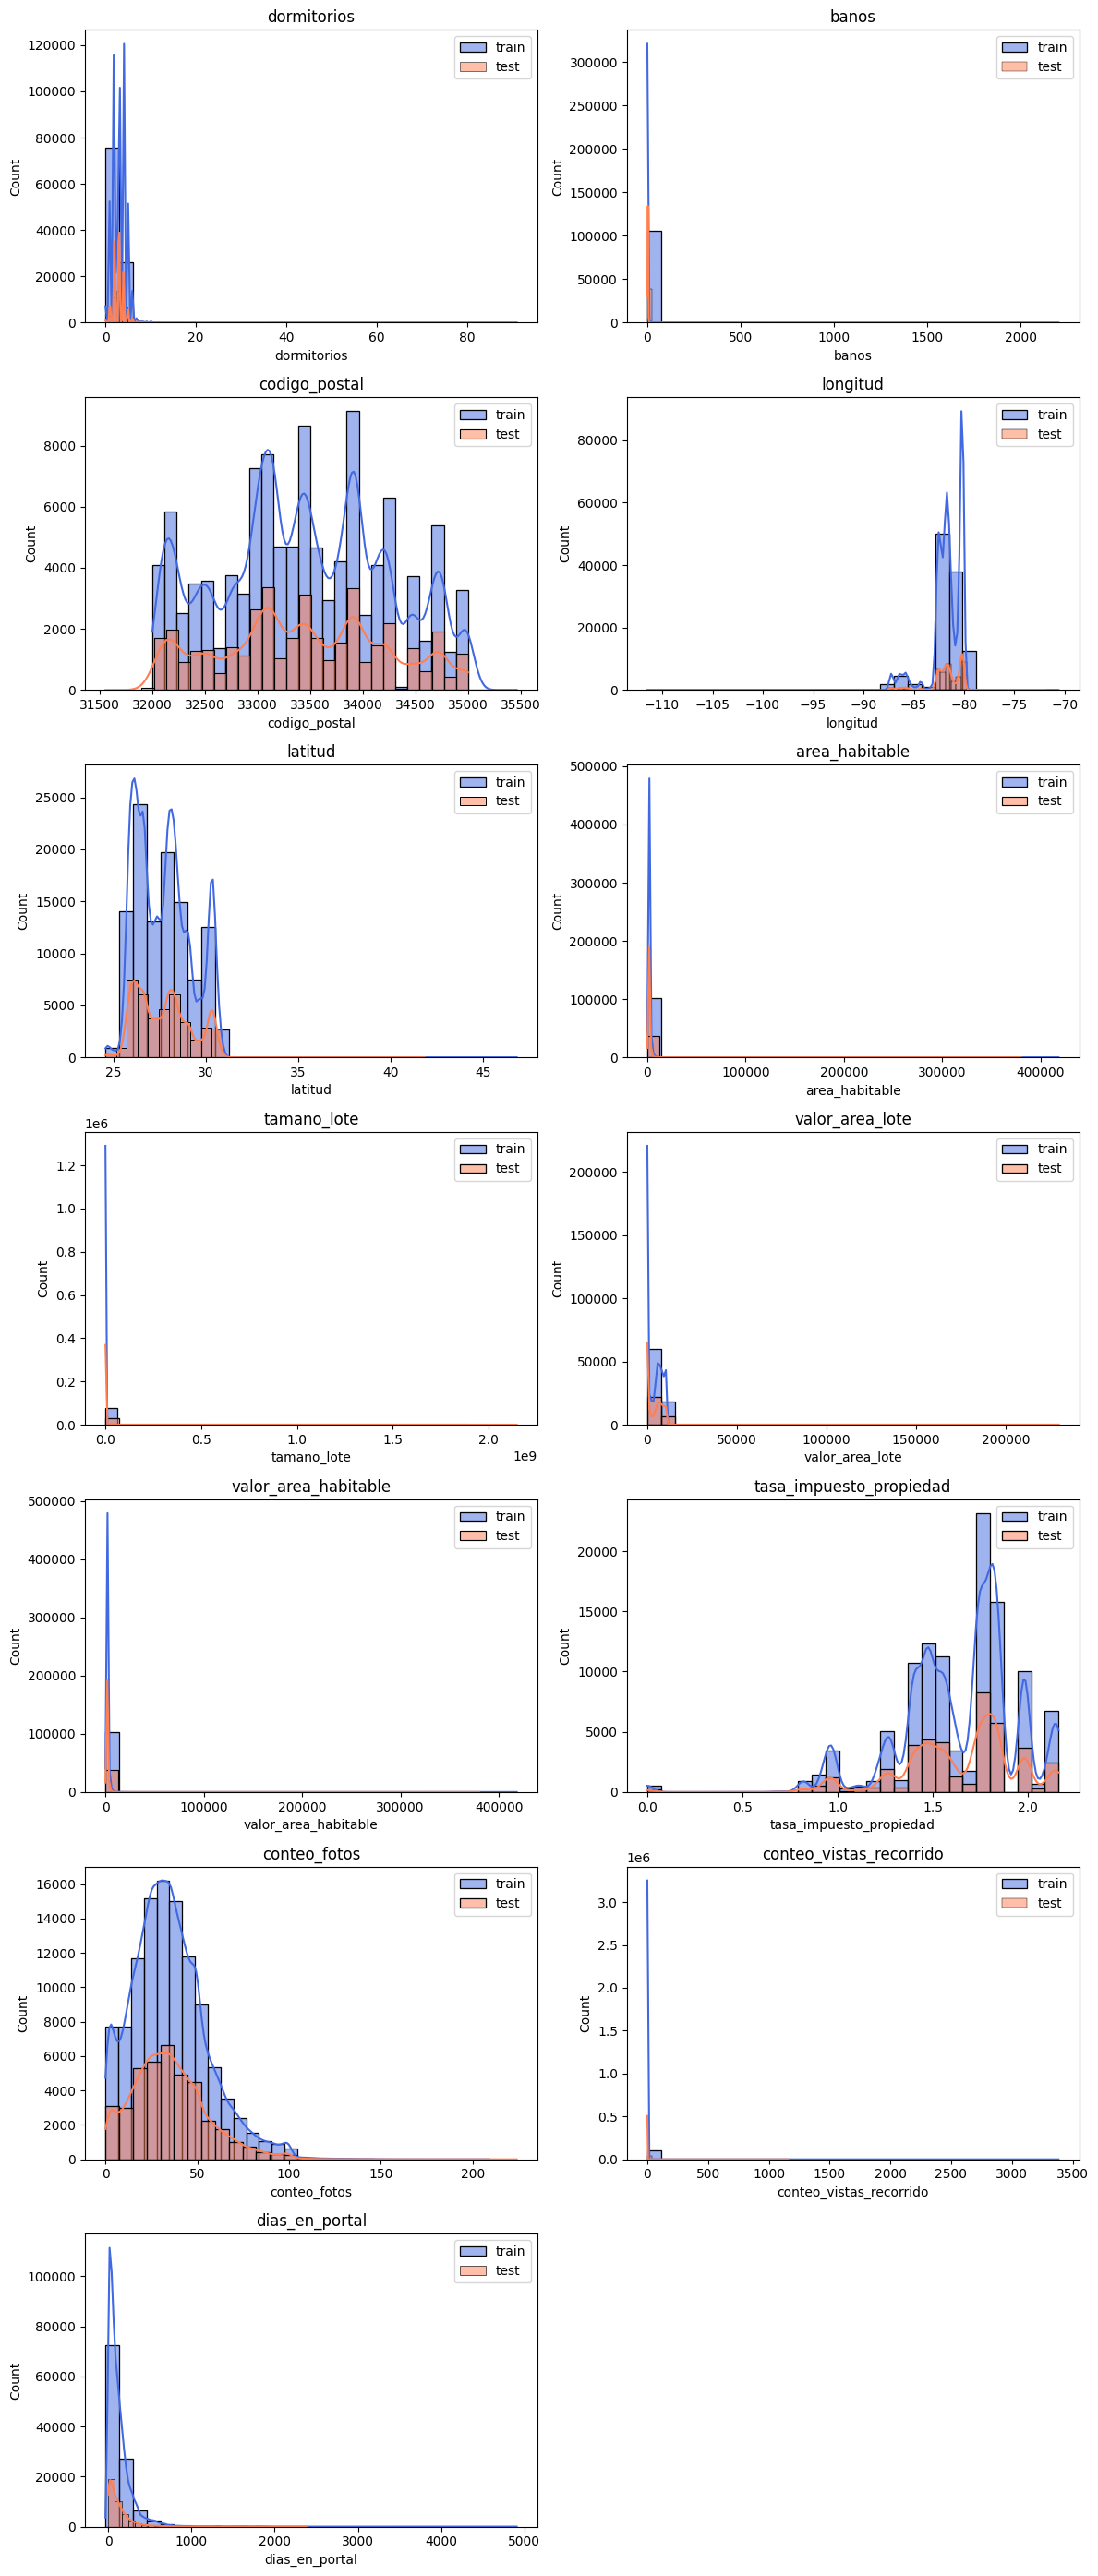

In [12]:
numerical_FEATURES = train_df[numerical_FEATURES].describe().T.index.tolist()

n_cols = 2
n_rows = (len(numerical_FEATURES) + n_cols - 1) // n_cols  # redondeo hacia arriba
fig, axes = plt.subplots(n_rows, n_cols, figsize = (12,n_rows*4))
axes = axes.flatten()  # facilita indexar los subplots

for i, feature in enumerate(numerical_FEATURES):
    sns.histplot(train_df[feature], kde=True, bins = 30, ax=axes[i], color="royalblue",label="train")
    sns.histplot(test_df[feature], kde=True, bins=30, ax = axes[i], color="coral",label="test")
    axes[i].set_title(feature)
    axes[i].legend()

# Apagar ejes vacíos (si los hay)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

Como puede observarse en los gráficos hay muchos features skewed, por ejemplo: 

Right skewed: 
- Dormitorios
- banos
- precio
- area habitable
- tamano lote
- valor_area_lote
- valor_area_habitable
- conteo_vistas_recorrido
- dias en portal
- dias_en_portal_detalle

Tendrá que decidirse que hacer con los valores atípicos para los features right skewed y como inputar los NaN

**El codigo postal es una variable numérica pero no debería usarse como variable continua porque no tiene relacion ordinal, las distancias numericas no representan distancias geograficas reales. Lo mejor es hacer one hot encoding**

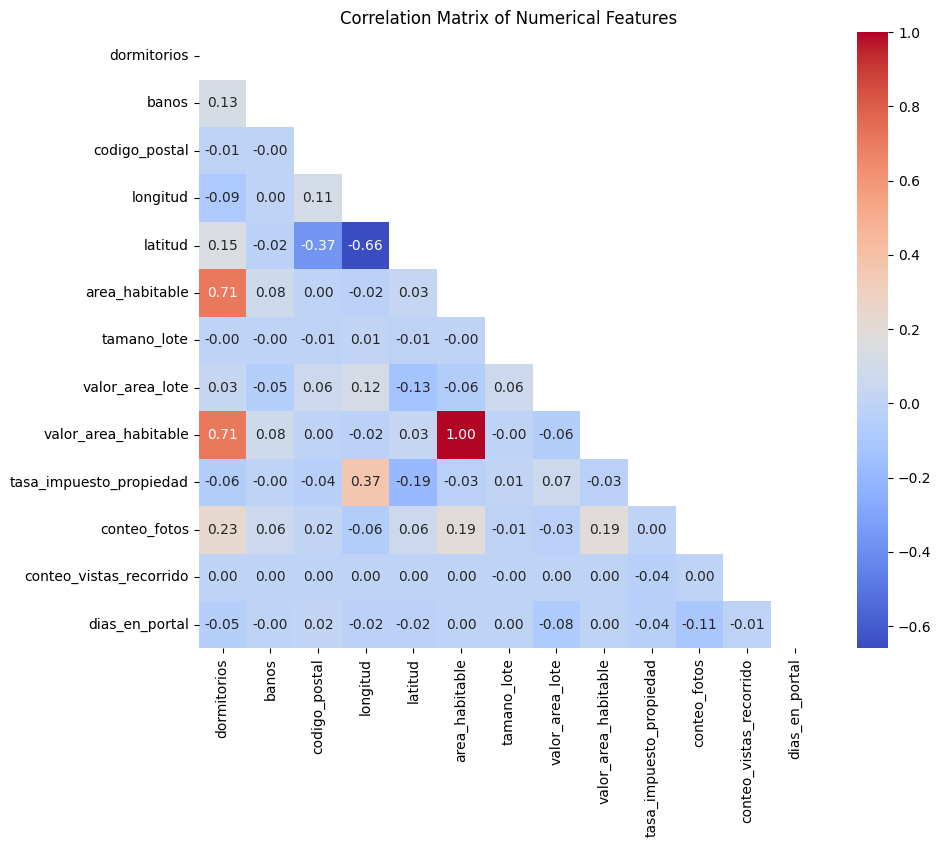

In [13]:
# Correlación entre variables numéricas
mask = np.triu(np.ones_like(train_df[numerical_FEATURES].corr().round(2), dtype=bool))
correlation_matrix = train_df[numerical_FEATURES].corr().round(2)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm",mask=mask, fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

Como puede verse en la matriz de correlación, hay variables altamente correladas: 
- Area habitable y valor area habitable con dormitorios
- Dias en portal con dias en portal detalle es prácticamente lo mismo

In [14]:
train_df[numerical_FEATURES].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110000 entries, 0 to 109999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   dormitorios              102884 non-null  float64
 1   banos                    106172 non-null  float64
 2   codigo_postal            110000 non-null  int64  
 3   longitud                 109666 non-null  float64
 4   latitud                  109666 non-null  float64
 5   area_habitable           102508 non-null  float64
 6   tamano_lote              77650 non-null   float64
 7   valor_area_lote          77653 non-null   float64
 8   valor_area_habitable     102519 non-null  float64
 9   tasa_impuesto_propiedad  109963 non-null  float64
 10  conteo_fotos             110000 non-null  int64  
 11  conteo_vistas_recorrido  109963 non-null  float64
 12  dias_en_portal           109968 non-null  float64
dtypes: float64(11), int64(2)
memory usage: 10.9 MB


In [15]:
# Hay variables que parece que supuestamente son lo mismo pero tienen valores distintos
train_df[(train_df['tamano_lote']!= train_df['valor_area_lote'])][['tamano_lote','valor_area_lote']]

,tamano_lote,valor_area_lote
0,NaN,NaN
1,NaN,NaN
2,11761.0,0.270000
3,7100.0,7100.280000
4,NaN,NaN
...,...,...
109990,16004.0,0.367401
109994,20473.0,0.470000
109995,159656.0,3.665200
109996,23958.0,0.550000


### 3.2. Analizar non-numerical features
Objetivo: 
- Determinar cuales son variables categoricas y su cardinalidad
- Determinar de los non-numerical features cuales deberían ser preprocesados para acceder a la información (json format etc.)
- Ver que features son binarios


In [16]:
non_numerical_FEATURES = [f for f in train_df.columns if f not in numerical_FEATURES + FEATURES2DROP + [TARGET]]
len(non_numerical_FEATURES)

47

In [17]:
def info_con_cardinalidad(df):
    return pd.DataFrame({
        "dtype": df.dtypes,
        "non_nulls": df.notnull().sum(),
        "nulls": df.isnull().sum(),
        "cardinalidad": df.nunique(dropna=True)
    })

In [18]:
info_con_cardinalidad(train_df[non_numerical_FEATURES])

,dtype,non_nulls,nulls,cardinalidad
ciudad,object,110000,0,742
estado,object,110000,0,1
estado_propiedad,object,110000,0,1
geocodificacion_deficiente,object,9521,100479,2
tipo_vivienda,object,110000,0,10
unidades_area_lote,object,109968,32,3
unidades_area_habitable_corto,object,7535,102465,1
direccion_no_divulgada,object,109968,32,2
fecha_venta_texto,object,5004,104996,3143
pais,object,110000,0,1


De la distribución de cardinalidades podemos: 
- Establecer cuales son variables categoricas
- Eliminar variables constantes que no aportaran información ni explicabilidad para la variable target --> Carga innecesaria: 
    - estado
    - estado_propiedad
    - pais
    - es_destacado: Elimino porque solo hay un valor asignado y es False. Si almenos estuvieran contemplados solo los True podria etiquetar el resto como False. Pero no es así. 
    - es_conector_vivienda: Elimino porque solo hay un valor asignado y es False. Si almenos estuvieran contemplados solo los True podria etiquetar el resto como False. Pero no es así. 
    - limite_clientes_renta: Elimino porque solo hay un valor asignado y es False. Si almenos estuvieran contemplados solo los True podria etiquetar el resto como False. Pero no es así. 
    - listado_por_administracion

- Hay variables con demasiada presencia NaN donde imputar los NaN no tiene mucho sentido debido al poco conocimiento. Se harían assumptions poco fundamentadas: 


- Hay variables que me tienen un poco descolocado: "ocupado no propietario" que indica si esta alquilado o no puede ser muy relevante, pero la gran mayoría de los valores son NaN


In [ ]:
# Variables donde hay demasiado null y demasiada cardinalidad para ser útiles

non_numerical_FEATURES2DROP = [
    'estado', # Solo 1 categoria
    'estado_propiedad', # Solo 1 categoria
    'pais', # Solo 1 categoria
    'ocupado_no_propietario',
    'escuelas', # Demasiados nulls, cardinalidad mjy alta
    'oferta_inmediata_habilitada', # Solo 1 categoría
    'vecindarios_cercanos', # Demasiados nulls
    'codigos_postales_cercanos', # Demasiados nulls
    'nombre_corredor', # Demasiados nulls, cardinalidad altisima
    'es_destacado',# Solo 1 categoría, demasiados nulls
    'es_conector_vivienda',# Solo 1 categoría, demasiados nulls
    'limite_clientes_renta', # Solo 1 categoría, demasiados nulls
    'avaluo_vivienda', # Demasiados nulls
    'fuera_del_mercado', # solo 1 categoría 
    'condado', # Poca información, con la ciudad suficiente. Mucho NaN. Se podría llegar a asociar las ciudades a sus condados. No se si sería relevante. 
    'listado_por_administracion', # solo 1 categoria
    'fecha_venta_texto', # demasiados
    'tasas_hipoteca', # demasiados nulls
    'ciudades_cercanas', # Cardinalidad muy alta. El efecto de esta variable ya se verá reflejado en la variable "ciudad"
    'dimension_tipo_hdp', # La gran mayoria es for sale. Aporta poco valor la otra categoría
    'dimension_tipo_publicacion', # Decido eliminarla ya que la cardinalidad es > 15 y nose como imputar los NaNs
    'unidades_area_habitable_corto', # Prescindimos de ello, ya tenemos unidades de area lote
    'unidades_area_habitable' # Lo unico informado es en sqft, lo otro es NaN. Todo sería sqft asi que no lo consideramos
    ] 

# Se han observado ciertos features que requieren de un preprocesado porque la información proviene de un 
non_numerical_FEATURES2EXTRACT = [
    'descripcion', # TODO: embeddings
    'servicios',
    'fecha_venta',
    'interior',
    'resumen',
    'interior_completo',
    'construccion',
    'detalles_comunidad',
    'puntajes_movilidad',
    'movilidad',
    'riesgos_climaticos' # TODO: EXTRAER
    ]

categorical_FEATURES = [f for f in train_df.columns if f not in numerical_FEATURES + FEATURES2DROP + [TARGET] + non_numerical_FEATURES2DROP + non_numerical_FEATURES2EXTRACT]
len(categorical_FEATURES)

13

In [20]:
info_con_cardinalidad(train_df[categorical_FEATURES])

,dtype,non_nulls,nulls,cardinalidad
ciudad,object,110000,0,742
geocodificacion_deficiente,object,9521,100479,2
tipo_vivienda,object,110000,0,10
unidades_area_lote,object,109968,32,3
direccion_no_divulgada,object,109968,32,2
es_constructor_premier,object,109968,32,2
tiene_video_publico,object,5008,104992,1
url_tour_virtual_tercero_aprobado,object,106938,3062,2
dimension_tipo_propiedad,object,109968,32,8
zona_horaria,object,109937,63,4


### 3.3. Imputación de NaN

#### Variables no numéricas

In [21]:
## Geocodificacion deficiente
# Aunque la mayoria de los datos son NaN consideraremos que la geocodificación es precisa
train_df['geocodificacion_deficiente'] = train_df['geocodificacion_deficiente'].fillna(False)

## Direccion no divulgada
# La gran mayoría de los casos son False, por lo que los NaNs los sustituiremos por False
train_df['direccion_no_divulgada'] = train_df['direccion_no_divulgada'].fillna(False)

## Es constructor premier
# La gran mayoria de los casos son False, por lo que los NaNs los sustituiremos por False
train_df['es_constructor_premier'] = train_df['es_constructor_premier'].fillna(False)

## Tiene video publico 
# Solo se informan los False por lo que entendemos que los NaN son True
train_df['tiene_video_publico'] = train_df['tiene_video_publico'].fillna(True)


## url_tour_virtual_terceros
# Rellenamos los Nan con el valor con mayor frecuencia --> False
train_df['url_tour_virtual_tercero_aprobado'] = train_df['url_tour_virtual_tercero_aprobado'].fillna(False)

## Zona horaria
# Mirar la ciudad de los NaN para zona horaria y sustituir por la zona horaria correspondiente
ciudades2check_zona_horaria = list(train_df[train_df['zona_horaria'].isna()][['ciudad','zona_horaria']]['ciudad'].unique())# Estas son las ciudades que tienen NaN
filtered_ciudades2check_df= train_df[train_df['ciudad'].isin(ciudades2check_zona_horaria)][['ciudad','zona_horaria']].dropna().sort_values(by='ciudad')

# Hay casos donde el value_counts es 1 o hay discrepancias en algunas casuísticas. No solo en las ciudades a selecionar sino en las demás va a suceder. 
# Por lo que decido seleccionar la zona horaria por ciudad con más frecuencia de aparición. 
zona_horaria_dominante = (train_df.groupby("ciudad")["zona_horaria"].agg(lambda x: x.value_counts().idxmax()))
train_df['zona_horaria'] = train_df['ciudad'].map(zona_horaria_dominante)

## Eligibilidad recorrido
# En el caso de la elegibilidad del recorrido el contenido está distribuido en binarios (True/False) y NaNs. Sin embargo, el binario se encuentra dentro de un diccionario. 
# Extraigo el valor del diccionario y lo asigno a la columna. En el caso de NaNs los sustituyo por True ya que la mayoría de los casos son True.
train_df['elegibilidad_recorrido'] = train_df['elegibilidad_recorrido'].apply(lambda x: json.loads(x) if isinstance(x,str) else x)
train_df['elegibilidad_recorrido'] = train_df['elegibilidad_recorrido'].apply(lambda x: x['isPropertyTourEligible'] if isinstance(x, dict) else x)
train_df['elegibilidad_recorrido'] = train_df['elegibilidad_recorrido'].fillna(True)

## Auto recorrido
# Lo mismo para el feature auto_recorrido. Pero debido a la mayor volumetría de False, los NaNs los sustituiré por False.
train_df['auto_recorrido'] = train_df['auto_recorrido'].apply(lambda x: json.loads(x) if isinstance(x,str) else x)
# Hay un diccionario vacío que da problemas, lo reemplazaremos por un NaN
train_df['auto_recorrido'] = train_df['auto_recorrido'].apply(lambda x: False if x == {} else x)
train_df['auto_recorrido'] = train_df['auto_recorrido'].apply(lambda x: x['hasSelfTour'] if isinstance(x, dict) else x) 
train_df['auto_recorrido'] = train_df['auto_recorrido'].fillna(False)

## Es mostrado
# Solo hay un NaN en es_mostrado, lo rellenamos con la mayoría --> False
train_df['es_mostrado'] = train_df['es_mostrado'].fillna(False)


# Seleccionamos como unidad de area habitable "unidades_area_lote"
# estandarizamos. Los NaN seran sqft y los Square Feet los transformaremos a sqft
train_df['unidades_area_lote'] = train_df['unidades_area_lote'].fillna('sqft')
train_df['unidades_area_lote'] = train_df['unidades_area_lote'].replace('Square Feet', 'sqft')


# Los NaN de dimension_tipo_propiedad se encuentran dentro de la columna "construccion" --> Extraer y sustituir
train_df['construccion'] = train_df['construccion'].apply(lambda x: ast.literal_eval(x) if isinstance(x,str) else x)


In [22]:
def extraer_home_type(item):
    if not isinstance(item, list):
        return None
    
    for bloque in item:
        if bloque.get('title') == 'Type & style':
            for valor in bloque.get('values', []):
                if valor.startswith("Home type:"):
                    return valor.split("Home type:")[1].strip()
    return None


def extraer_year_built(item):
    if not isinstance(item, list):
        return None
    
    for bloque in item:
        for valor in bloque.get('values', []):
            if valor.startswith("Year built:"):
                return valor.split("Year built:")[1].strip()
    return None

train_df['extracted_dimension'] = train_df['construccion'].apply(extraer_home_type)


# Haremos un mapeo de los tipos para tenerlo en un mismo formato y unificar. 
# En los casos de None pondremos other
# Consideraremos la información buena la extracted dimension
train_df['extracted_dimension'] = train_df['extracted_dimension'].replace('None','Other')
train_df['extracted_dimension'] = train_df['extracted_dimension'].replace('Unknown','Other')
train_df['extracted_dimension'] = train_df['extracted_dimension'].fillna('Other')



train_df['year_built'] = train_df['construccion'].apply(extraer_year_built)
# Hay años de construccion que son 0, noaportan mucho valor. Que hacemos con los year built y los Nan? Pendiente revisar. 
# train_df[(~train_df['anio_construccion'].isna()) & (train_df['year_built'].isna())][['anio_construccion','year_built']]


In [23]:
# Vuelvo a ver la distribución de cardinalidad y nulos en las variables no numéricas tras la imputación 
# Quito de categorical features dimension_tipo_propiedad y añado extracted dimension 

categorical_FEATURES = categorical_FEATURES + ['extracted_dimension']
categorical_FEATURES = [f for f in categorical_FEATURES if f != 'dimension_tipo_propiedad']
info_con_cardinalidad(train_df[categorical_FEATURES])


,dtype,non_nulls,nulls,cardinalidad
ciudad,object,110000,0,742
geocodificacion_deficiente,bool,110000,0,2
tipo_vivienda,object,110000,0,10
unidades_area_lote,object,110000,0,2
direccion_no_divulgada,bool,110000,0,2
es_constructor_premier,bool,110000,0,2
tiene_video_publico,bool,110000,0,2
url_tour_virtual_tercero_aprobado,bool,110000,0,2
zona_horaria,object,110000,0,2
elegibilidad_recorrido,bool,110000,0,2


#### Variables numéricas

In [26]:
# Imputación de variables numéricas 

# Se puede ver que en algunos casos es NaN en ambos y en otro no. En los casos en los que sean nan ambos estableceremos el valor a 0.
# En los otros casos cogeremos el valor que no sea NaN. Lo mismo para test_df.

train_df['dias_en_portal'] = train_df['dias_en_portal'].fillna(train_df['dias_en_portal_detalle'])
test_df['dias_en_portal'] = test_df['dias_en_portal'].fillna(test_df['dias_en_portal_detalle'])

train_df['dias_en_portal'] = train_df['dias_en_portal'].fillna(0)
test_df['dias_en_portal'] = test_df['dias_en_portal'].fillna(0)


## Nº de habitaciones --> Mediana
train_df['dormitorios'] = train_df['dormitorios'].fillna(train_df['dormitorios'].median())

## Nº de baños --> Moda
train_df['banos'] = train_df['banos'].fillna(train_df['banos'].mode()[0])

## Tasa de impuesto de propiedad --> Ajustarla por codigo_postal a la mediana del valor del codigo postal
train_df['tasa_impuesto_propiedad'] = train_df.groupby('codigo_postal')['tasa_impuesto_propiedad'].transform(lambda x: x.fillna(x.median()))
# Puede ser que el ccodigo postal tenga todo los valores como Nan. Si eso es así, imputamos con la mediana global 
train_df['tasa_impuesto_propiedad'] = train_df['tasa_impuesto_propiedad'].fillna(train_df['tasa_impuesto_propiedad'].median())


# Para latitud y longitud considerar la mediana por zona
train_df['latitud'] = train_df.groupby('codigo_postal')['latitud'].transform(lambda x: x.fillna(x.mean()))
train_df['longitud'] = train_df.groupby('codigo_postal')['longitud'].transform(lambda x: x.fillna(x.mean()))

# Para area habitable imputar la mediana dentro de grupos que combinen la variable baños, y la extracted dimension
train_df['area_habitable'] = (train_df.groupby(['dormitorios', 'banos', 'extracted_dimension'])['area_habitable'].transform(lambda x: x.fillna(x.median())))
# Puede ser que todas las agrupaciones sean Nan rellenamos con la mediana global 
train_df['area_habitable'] = train_df['area_habitable'].fillna(train_df['area_habitable'].median())

# Rellenamos con la moda el conteo vistas recorrido
train_df['conteo_vistas_recorrido'] = train_df['conteo_vistas_recorrido'].fillna(train_df['conteo_vistas_recorrido'].mode()[0])

- Momentaneamente dropearemos la información: 
    - tamano_lote
    - valor_area_lote
    - valor_area_habitable

In [28]:
numerical_FEATURES = [f for f in numerical_FEATURES if f not in ['tamano_lote','valor_area_lote','valor_area_habitable']]

In [29]:
train_df[numerical_FEATURES].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110000 entries, 0 to 109999
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   dormitorios              110000 non-null  float64
 1   banos                    110000 non-null  float64
 2   codigo_postal            110000 non-null  int64  
 3   longitud                 110000 non-null  float64
 4   latitud                  110000 non-null  float64
 5   area_habitable           110000 non-null  float64
 6   tasa_impuesto_propiedad  110000 non-null  float64
 7   conteo_fotos             110000 non-null  int64  
 8   conteo_vistas_recorrido  110000 non-null  float64
 9   dias_en_portal           110000 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 8.4 MB


In [ ]:
FEATURES = numerical_FEATURES + categorical_FEATURES